## Download and import the required libraries

In [1]:
import os
import torch
os.environ['TORCH'] = torch.__version__

!pip install torch_geometric
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

import numpy as np
import time
import warnings
import torch.nn.functional as F
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import TUDataset
from torch_geometric.transforms import OneHotDegree
from torch_geometric.utils import degree
from torch_geometric.nn import GINConv, global_add_pool, global_mean_pool
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE
try:
    import umap.umap_ as umap
except ImportError:
    import umap
import random
import copy

os.makedirs('./best_models', exist_ok=True)
os.makedirs('./plots', exist_ok=True)
os.makedirs('./results', exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.1 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 95.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 65.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


2026-02-06 18:57:38.009532: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770404258.213524      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770404258.271887      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770404258.756117      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770404258.756152      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770404258.756155      55 computation_placer.cc:177] computation placer alr

# Load the Dataset

In [2]:
import torch_geometric.transforms as T

def get_dataset(name):
    if (name == 'MUTAG'):
        dataset = TUDataset(root='./data', name=name, use_node_attr=True)
        
    elif (name=='ENZYMES'):
        dataset = TUDataset(
            root='./data', 
            name='ENZYMES',
            use_node_attr=True,  # Ensure continuous features are loaded
            transform=T.Compose([
                T.NormalizeFeatures(), # Normalize the continuous features
                T.OneHotDegree(max_degree=15) # Adds structural degree info
            ])
        )

    else: 
        dataset = TUDataset(root='./data', name=name, use_node_attr=True)

        # Handle datasets with no node feature by adding one-hot encoded node degrees as features
        max_degree = 0
        for data in dataset:
            d = degree(data.edge_index[0], dtype=torch.long)
            max_degree = max(max_degree, int(d.max()))
        
        # Apply the transform to generate features
        dataset.transform = OneHotDegree(max_degree)
    
    return dataset

# GIN Architecture

In [3]:
class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5, num_layers=3):
        super().__init__()
        self.dropout = dropout
        self.num_layers = num_layers

        # Layer 0: Mapping input features to hidden dimension
        # so it has the same weight as the rest of the layers in the final embedding
        self.conv_zero = Sequential(
            Linear(in_channels, hidden_channels),
            BatchNorm1d(hidden_channels),
            ReLU()
        )

        # Layers 1 - K: GIN convolutions
        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            mlp = Sequential(
                Linear(hidden_channels, hidden_channels),
                BatchNorm1d(hidden_channels),
                ReLU(),
                Linear(hidden_channels, hidden_channels),
                BatchNorm1d(hidden_channels),
                ReLU()
            )
            conv = GINConv(mlp, train_eps=True)
            self.convs.append(conv)
        
        # Classifier
        # Input dim is hidden_channels*(num_layers+1) because we concat Layer 0 + K layers
        self.lin1 = Linear(hidden_channels*(num_layers+1), hidden_channels)
        self.lin2 = Linear(hidden_channels, out_channels)
    
    def forward(self, x, edge_index, batch):
        x = self.conv_zero(x)
        node_embeddings = [x]

        # Node Embeddings (for every GIN Layer)
        # [nodes_in_batch, hidden_dimension] * (num_layers + 1)
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.dropout(x, p=self.dropout, training=self.training)
            node_embeddings.append(x)

        # Graph-level readout of node embeddings to produce Graph Embeddings (at each layer)
        # We avg the node embeddings at each graph to produce a Graph Embedding 
        # [batch_size, hidden_dimension] * (num_layers + 1)
        pooled = [global_mean_pool(h, batch) for h in node_embeddings]
            
        # Concatenate graph embeddings from all layers
        # [batch_size, hidden_dimension * (num_layers + 1)] = [batch_size, embedding_size]
        graph_embedding = torch.cat(pooled, dim=1)

        # Classifier
        h = self.lin1(graph_embedding)
        h = h.relu()
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.lin2(h)

        return F.log_softmax(out, dim=1), F.softmax(out, dim=1), graph_embedding


def train(model, train_loader, optimizer):
    model.train()
    total_loss = 0
    total_graphs = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out, _, _ = model(data.x, data.edge_index, data.batch)
        
        loss = F.nll_loss(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs 
        total_graphs += data.num_graphs
        
    return total_loss / total_graphs

def test(model, loader):
    model.eval()
    prediction_list, label_list, probabilities_list, embedding_list = [], [], [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            _, probabilities, embeddings = model(data.x, data.edge_index, data.batch)
            predictions = probabilities.argmax(dim=1)
            
            prediction_list.append(predictions.detach().cpu())
            label_list.append(data.y.detach().cpu())
            probabilities_list.append(probabilities.detach().cpu())
            embedding_list.append(embeddings.detach().cpu())
        
    y_pred = torch.cat(prediction_list).numpy()
    y_true = torch.cat(label_list).numpy()
    y_probs = torch.cat(probabilities_list).numpy()
    final_embeddings = torch.cat(embedding_list)
    
    return y_true, y_pred, y_probs, final_embeddings

# RUN EXPERIMENTS




============================== CLASSIFICATION - 16 ==============================


Processing...
Done!


[Fold 01] Acc: 1.0000 | F1: 1.0000 | AUC: 1.00 | Time: 5.47s
[Fold 02] Acc: 0.7895 | F1: 0.8667 | AUC: 0.79 | Time: 4.75s
[Fold 03] Acc: 0.6842 | F1: 0.8125 | AUC: 0.35 | Time: 4.65s
[Fold 04] Acc: 0.8947 | F1: 0.9231 | AUC: 0.86 | Time: 4.71s
[Fold 05] Acc: 0.7895 | F1: 0.8462 | AUC: 0.78 | Time: 4.72s
[Fold 06] Acc: 0.7368 | F1: 0.8276 | AUC: 0.71 | Time: 4.69s
[Fold 07] Acc: 0.7368 | F1: 0.7619 | AUC: 0.81 | Time: 4.64s
[Fold 08] Acc: 0.7895 | F1: 0.8571 | AUC: 0.90 | Time: 4.72s
[Fold 09] Acc: 0.8333 | F1: 0.8889 | AUC: 0.86 | Time: 4.69s
[Fold 10] Acc: 0.8333 | F1: 0.8696 | AUC: 0.86 | Time: 5.05s
------------------------------------------------------------
Final 10-Fold Results (MUTAG - EMB 16 - 150 EPOCHS):
Accuracy:        80.88% ± 8.49
F1-Score:        0.8653 ± 0.0611
AUC:             0.7926 ± 0.1659
Total Train Time:4.81s ± 0.25
Avg Inference:   0.0047s ± 0.0002
Peak Memory Use: 17.86 MB
------------------------------------------------------------


==========================

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


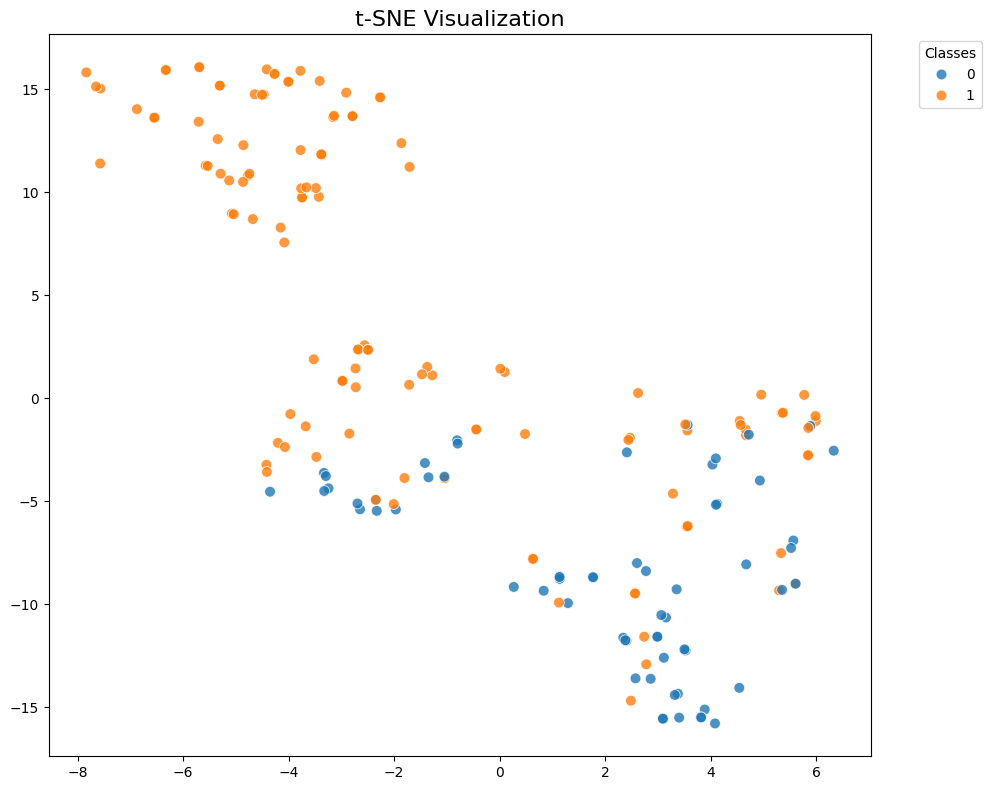

Saved: tSNE_MUTAG_16


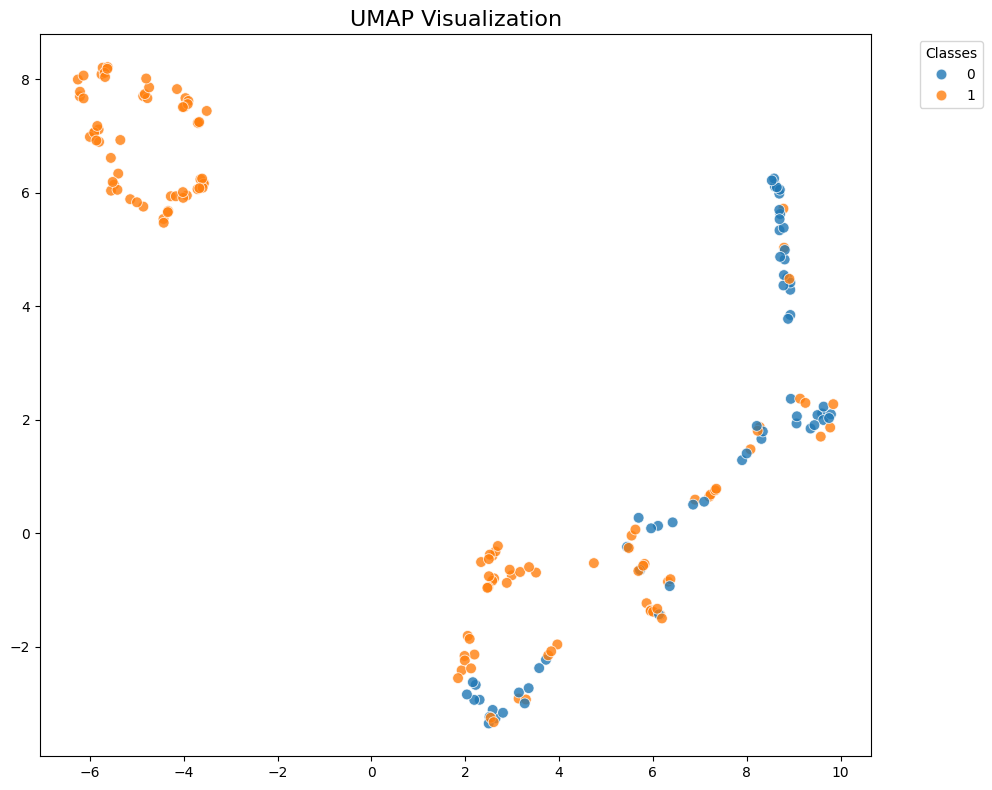

Saved: UMAP_MUTAG_16
-----------------------------------------
QUALITATIVE ASSESSMENT: Medium Separation
-----------------------------------------

============================== STABILITY ANALYSIS - 16 ==============================

[STABILITY] Computing baseline embeddings...
Baseline Accuracy: 0.8245

--- Running: Add Edges ---
Noise 5% | Stability: 0.9900 | Acc: 0.7819
Noise 10% | Stability: 0.9662 | Acc: 0.7660
Noise 15% | Stability: 0.9232 | Acc: 0.7979
Noise 20% | Stability: 0.8989 | Acc: 0.7500
Noise 25% | Stability: 0.8333 | Acc: 0.7553
Noise 30% | Stability: 0.7779 | Acc: 0.7340

--- Running: Drop Edges ---
Noise 5% | Stability: 0.9823 | Acc: 0.8351
Noise 10% | Stability: 0.9493 | Acc: 0.5479
Noise 15% | Stability: 0.9259 | Acc: 0.3511
Noise 20% | Stability: 0.9037 | Acc: 0.3351
Noise 25% | Stability: 0.8875 | Acc: 0.3351
Noise 30% | Stability: 0.8726 | Acc: 0.3351

--- Running: Mixed (Add+Drop) ---
Noise 5% | Stability: 0.9949 | Acc: 0.8138
Noise 10% | Stability: 0.9882 | A

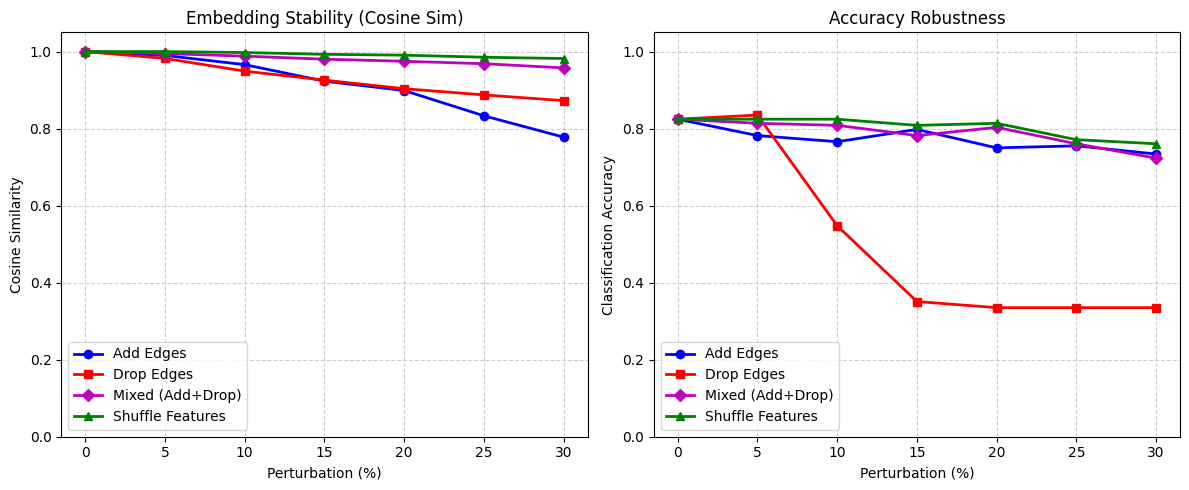


Saved full stability analysis to 'stability_analysis_MUTAG_16.png'



============================== CLASSIFICATION - 32 ==============================
[Fold 01] Acc: 0.9474 | F1: 0.9630 | AUC: 1.00 | Time: 4.74s
[Fold 02] Acc: 0.8947 | F1: 0.9286 | AUC: 0.99 | Time: 4.72s
[Fold 03] Acc: 0.7895 | F1: 0.8462 | AUC: 0.85 | Time: 4.72s
[Fold 04] Acc: 0.9474 | F1: 0.9600 | AUC: 0.94 | Time: 4.71s
[Fold 05] Acc: 0.8947 | F1: 0.9167 | AUC: 0.92 | Time: 4.71s
[Fold 06] Acc: 0.7895 | F1: 0.8182 | AUC: 0.86 | Time: 4.65s
[Fold 07] Acc: 0.8947 | F1: 0.9167 | AUC: 0.94 | Time: 4.70s
[Fold 08] Acc: 0.8947 | F1: 0.9091 | AUC: 0.93 | Time: 4.67s
[Fold 09] Acc: 0.8333 | F1: 0.8571 | AUC: 0.86 | Time: 4.73s
[Fold 10] Acc: 0.7222 | F1: 0.8276 | AUC: 0.86 | Time: 4.69s
------------------------------------------------------------
Final 10-Fold Results (MUTAG - EMB 32 - 150 EPOCHS):
Accuracy:        86.08% ± 7.05
F1-Score:        0.8943 ± 0.0504
AUC:             0.9141 ± 0.0526
Total Train Time:4.70s ± 0

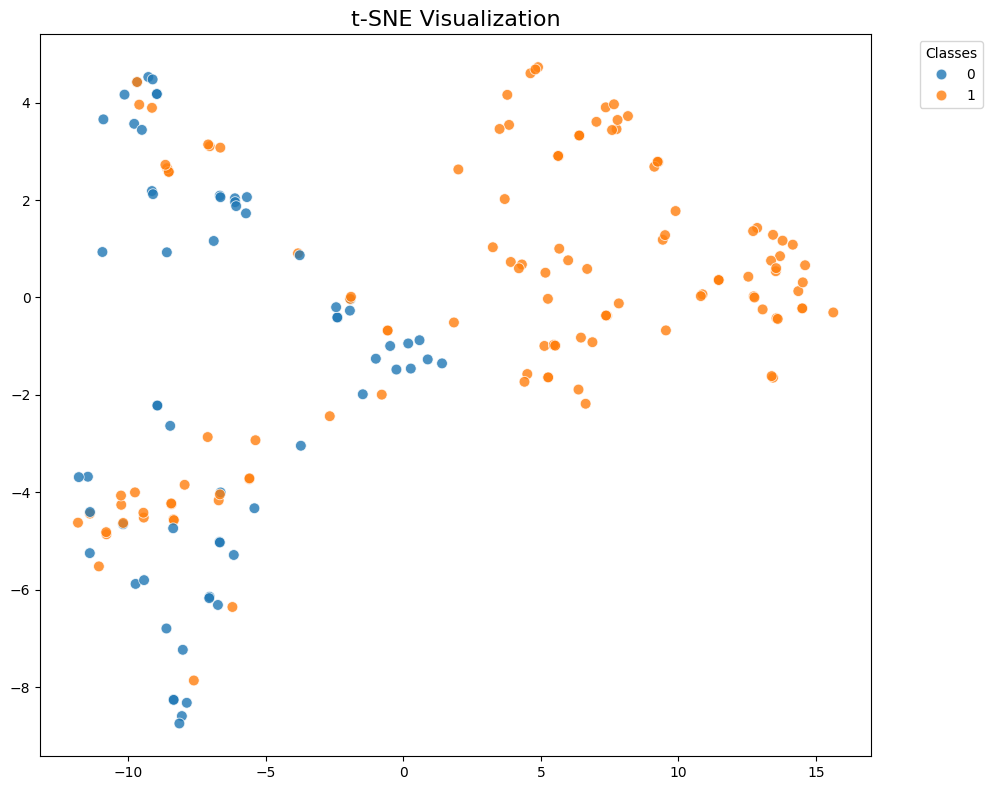

Saved: tSNE_MUTAG_32


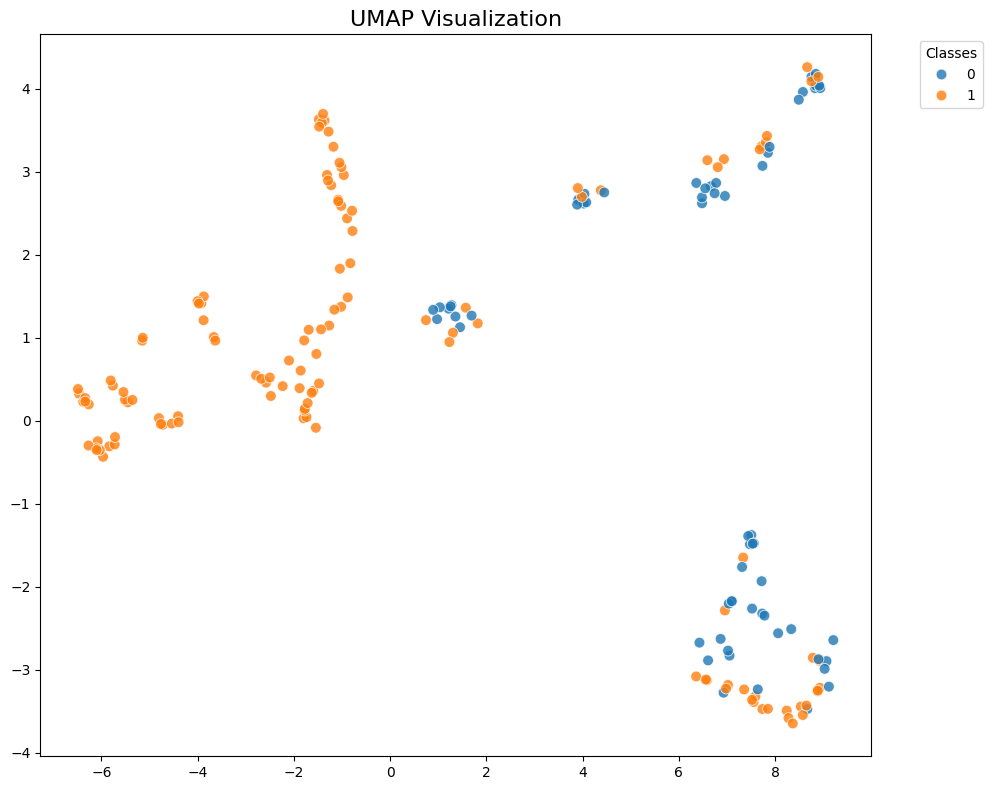

Saved: UMAP_MUTAG_32
-----------------------------------------
QUALITATIVE ASSESSMENT: Medium Separation
-----------------------------------------

============================== STABILITY ANALYSIS - 32 ==============================

[STABILITY] Computing baseline embeddings...
Baseline Accuracy: 0.7606

--- Running: Add Edges ---
Noise 5% | Stability: 0.9850 | Acc: 0.7660
Noise 10% | Stability: 0.9610 | Acc: 0.7713
Noise 15% | Stability: 0.9218 | Acc: 0.7819
Noise 20% | Stability: 0.8836 | Acc: 0.7713
Noise 25% | Stability: 0.8479 | Acc: 0.7553
Noise 30% | Stability: 0.8063 | Acc: 0.7340

--- Running: Drop Edges ---
Noise 5% | Stability: 0.9953 | Acc: 0.7606
Noise 10% | Stability: 0.9854 | Acc: 0.7447
Noise 15% | Stability: 0.9745 | Acc: 0.7074
Noise 20% | Stability: 0.9638 | Acc: 0.6702
Noise 25% | Stability: 0.9473 | Acc: 0.6170
Noise 30% | Stability: 0.9381 | Acc: 0.6277

--- Running: Mixed (Add+Drop) ---
Noise 5% | Stability: 0.9964 | Acc: 0.7606
Noise 10% | Stability: 0.9888 | A

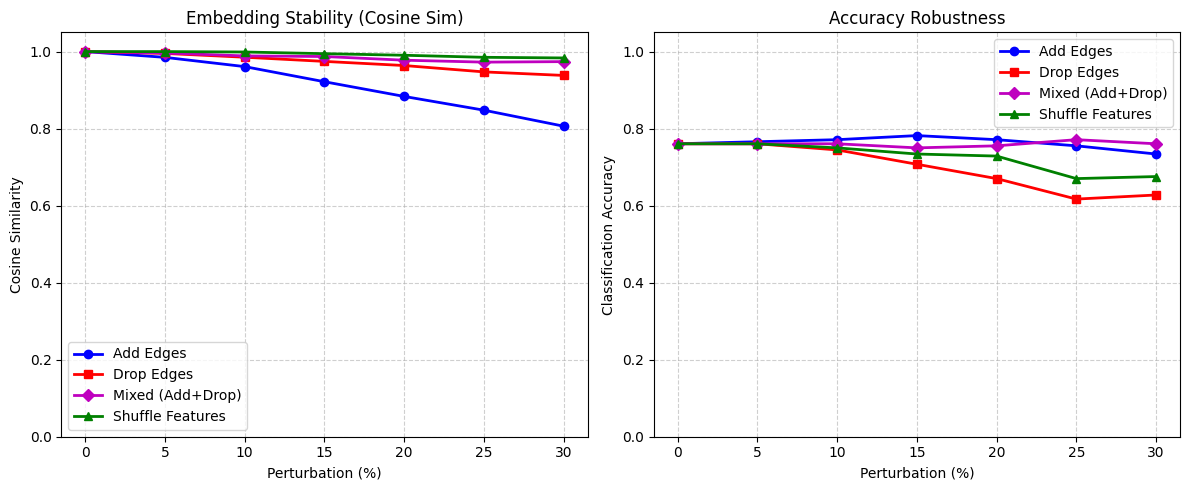


Saved full stability analysis to 'stability_analysis_MUTAG_32.png'



============================== CLASSIFICATION - 64 ==============================
[Fold 01] Acc: 0.9474 | F1: 0.9630 | AUC: 1.00 | Time: 4.72s
[Fold 02] Acc: 0.8947 | F1: 0.9286 | AUC: 0.95 | Time: 4.75s
[Fold 03] Acc: 0.9474 | F1: 0.9600 | AUC: 0.95 | Time: 4.70s
[Fold 04] Acc: 0.8947 | F1: 0.9231 | AUC: 0.92 | Time: 4.77s
[Fold 05] Acc: 0.8947 | F1: 0.9167 | AUC: 0.96 | Time: 4.78s
[Fold 06] Acc: 0.8947 | F1: 0.9091 | AUC: 0.90 | Time: 4.73s
[Fold 07] Acc: 0.8947 | F1: 0.9167 | AUC: 0.95 | Time: 4.78s
[Fold 08] Acc: 0.8947 | F1: 0.9091 | AUC: 0.90 | Time: 4.69s
[Fold 09] Acc: 0.8333 | F1: 0.8571 | AUC: 0.88 | Time: 4.77s
[Fold 10] Acc: 0.8333 | F1: 0.8571 | AUC: 0.86 | Time: 4.65s
------------------------------------------------------------
Final 10-Fold Results (MUTAG - EMB 64 - 150 EPOCHS):
Accuracy:        89.30% ± 3.61
F1-Score:        0.9140 ± 0.0337
AUC:             0.9280 ± 0.0402
Total Train Time:4.73s ± 0

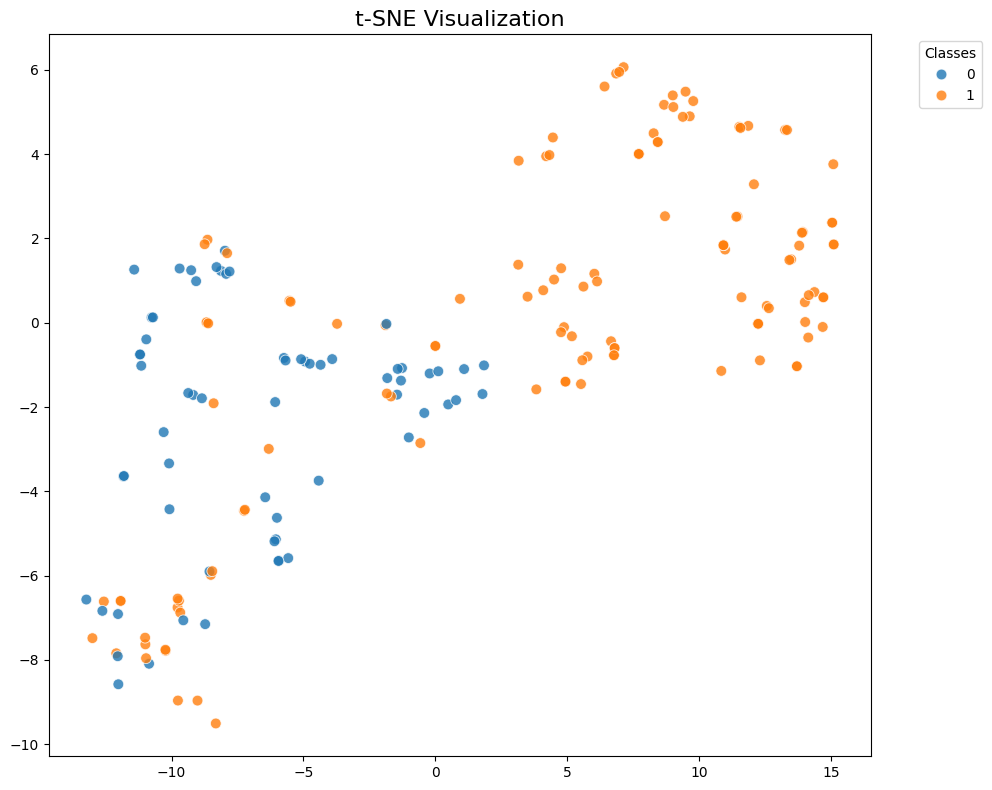

Saved: tSNE_MUTAG_64


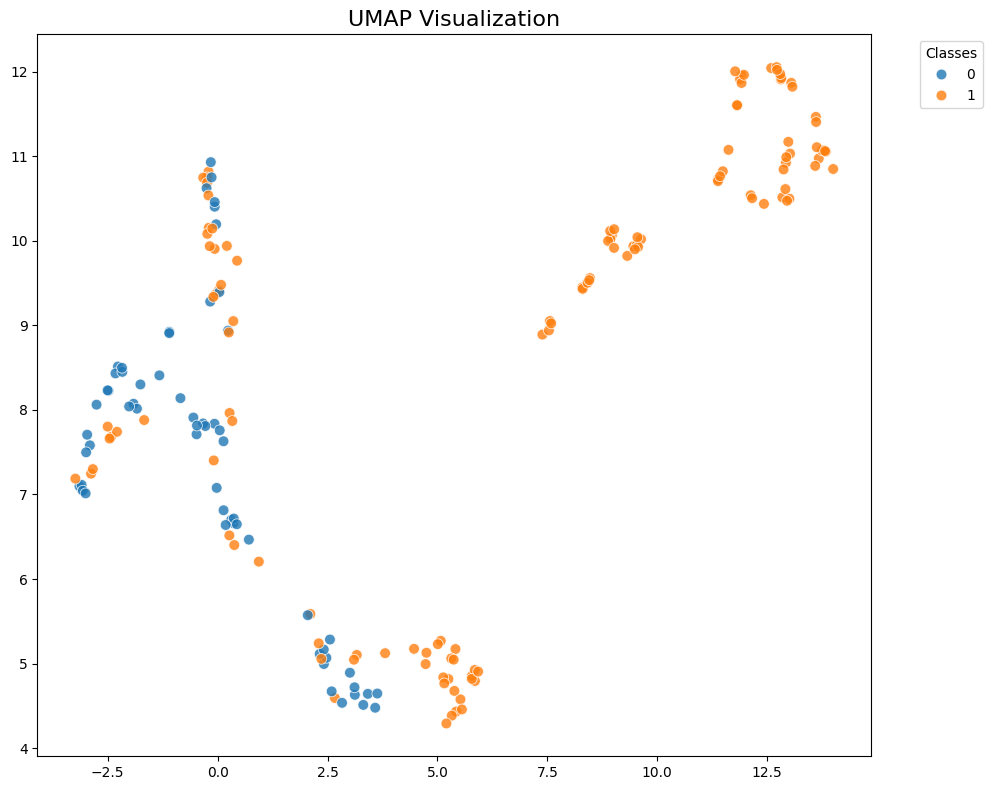

Saved: UMAP_MUTAG_64
-----------------------------------------
QUALITATIVE ASSESSMENT: Medium Separation
-----------------------------------------

============================== STABILITY ANALYSIS - 64 ==============================

[STABILITY] Computing baseline embeddings...
Baseline Accuracy: 0.7553

--- Running: Add Edges ---
Noise 5% | Stability: 0.9911 | Acc: 0.7553
Noise 10% | Stability: 0.9648 | Acc: 0.7766
Noise 15% | Stability: 0.9200 | Acc: 0.7234
Noise 20% | Stability: 0.8722 | Acc: 0.7021
Noise 25% | Stability: 0.7992 | Acc: 0.6915
Noise 30% | Stability: 0.7489 | Acc: 0.6809

--- Running: Drop Edges ---
Noise 5% | Stability: 0.9943 | Acc: 0.7660
Noise 10% | Stability: 0.9793 | Acc: 0.7766
Noise 15% | Stability: 0.9610 | Acc: 0.6277
Noise 20% | Stability: 0.9436 | Acc: 0.4894
Noise 25% | Stability: 0.9227 | Acc: 0.3404
Noise 30% | Stability: 0.9045 | Acc: 0.3351

--- Running: Mixed (Add+Drop) ---
Noise 5% | Stability: 0.9984 | Acc: 0.7660
Noise 10% | Stability: 0.9953 | A

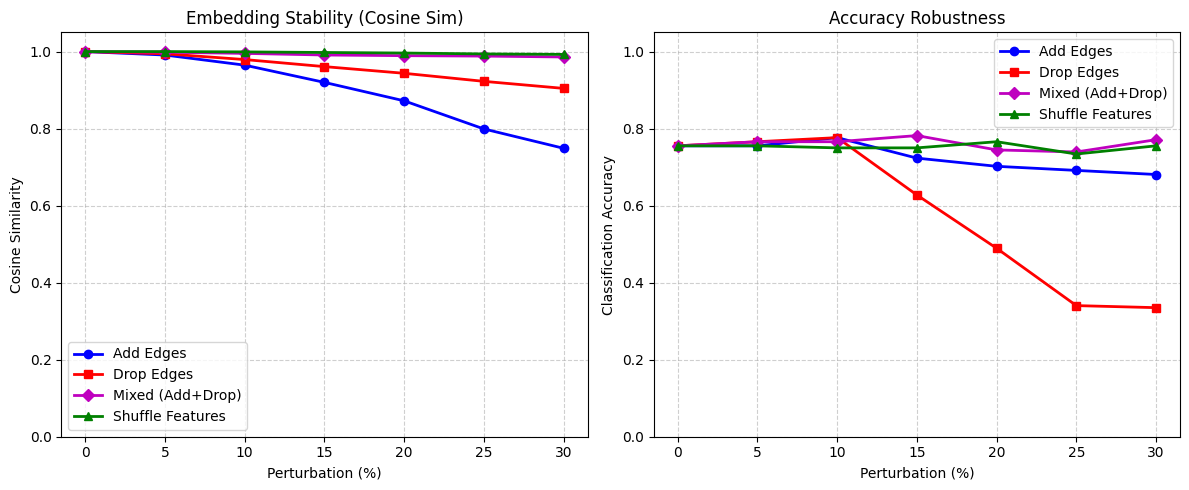


Saved full stability analysis to 'stability_analysis_MUTAG_64.png'



============================== CLASSIFICATION - 128 ==============================
[Fold 01] Acc: 0.9474 | F1: 0.9630 | AUC: 0.99 | Time: 4.72s
[Fold 02] Acc: 0.8947 | F1: 0.9286 | AUC: 0.91 | Time: 4.83s
[Fold 03] Acc: 0.9474 | F1: 0.9630 | AUC: 0.95 | Time: 4.75s
[Fold 04] Acc: 0.9474 | F1: 0.9600 | AUC: 0.96 | Time: 4.75s
[Fold 05] Acc: 0.9474 | F1: 0.9600 | AUC: 0.97 | Time: 4.83s
[Fold 06] Acc: 0.8947 | F1: 0.9091 | AUC: 0.95 | Time: 4.72s
[Fold 07] Acc: 0.8947 | F1: 0.9091 | AUC: 0.96 | Time: 4.73s
[Fold 08] Acc: 0.8947 | F1: 0.9091 | AUC: 0.88 | Time: 4.72s
[Fold 09] Acc: 0.8889 | F1: 0.9091 | AUC: 0.89 | Time: 4.74s
[Fold 10] Acc: 0.8889 | F1: 0.9167 | AUC: 0.90 | Time: 4.76s
------------------------------------------------------------
Final 10-Fold Results (MUTAG - EMB 128 - 150 EPOCHS):
Accuracy:        91.46% ± 2.68
F1-Score:        0.9328 ± 0.0241
AUC:             0.9371 ± 0.0360
Total Train Time:4.76s ±

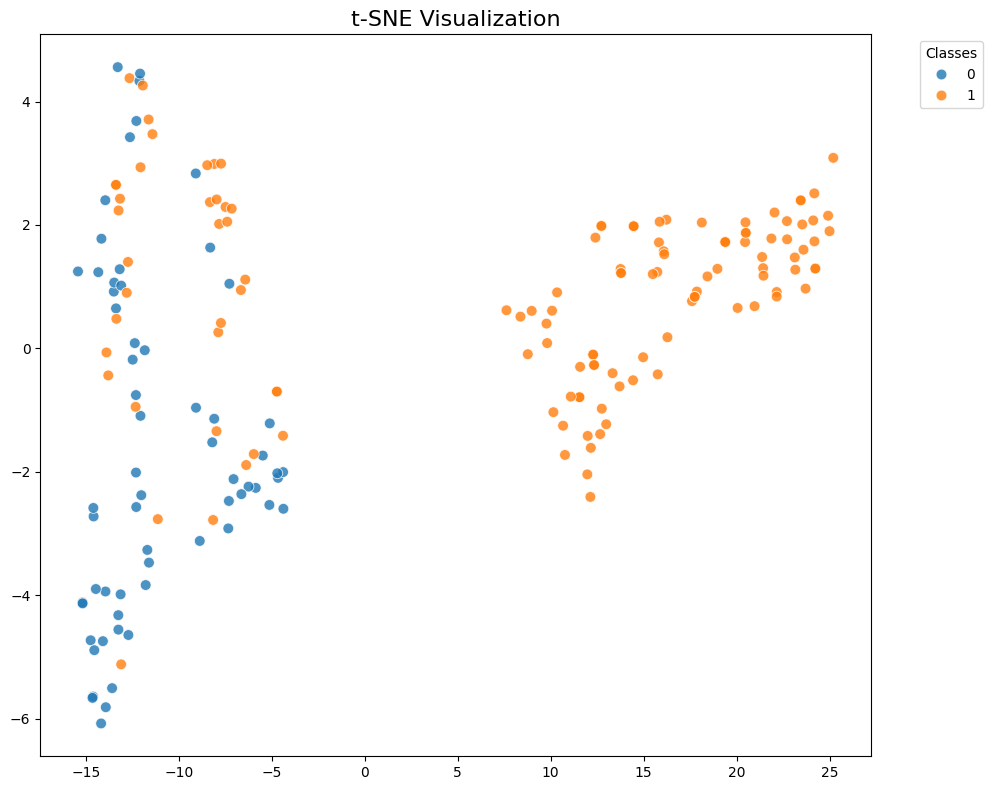

Saved: tSNE_MUTAG_128


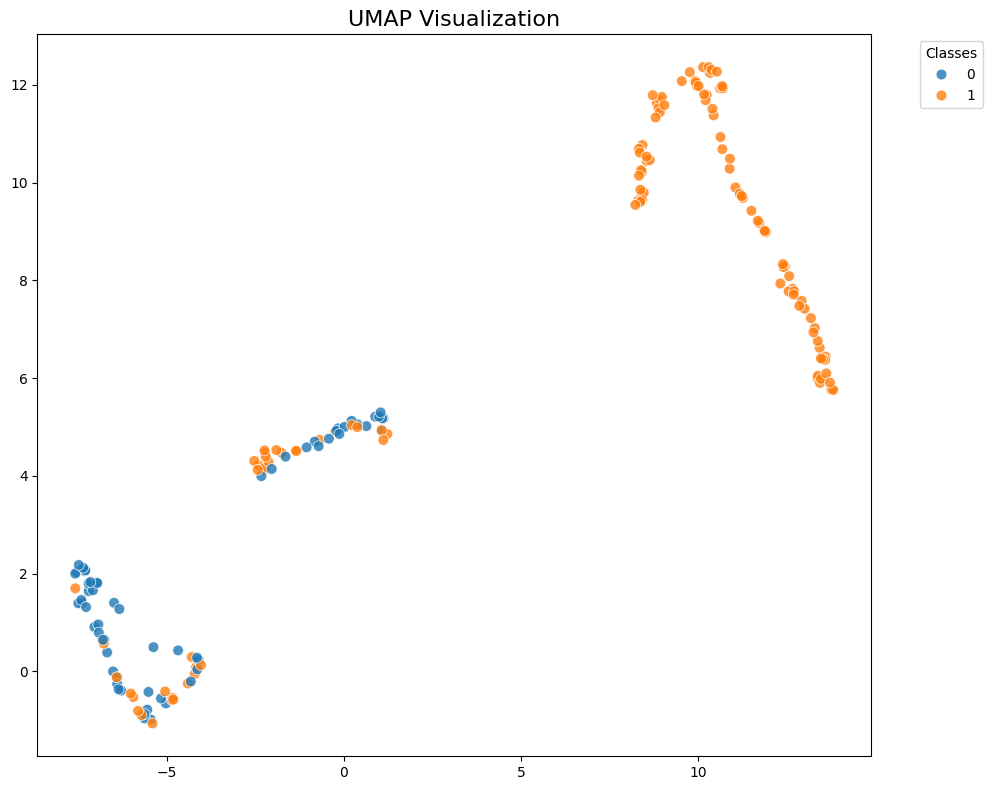

Saved: UMAP_MUTAG_128
-----------------------------------------
QUALITATIVE ASSESSMENT: Medium Separation
-----------------------------------------

============================== STABILITY ANALYSIS - 128 ==============================

[STABILITY] Computing baseline embeddings...
Baseline Accuracy: 0.8245

--- Running: Add Edges ---
Noise 5% | Stability: 0.9897 | Acc: 0.7926
Noise 10% | Stability: 0.9658 | Acc: 0.7819
Noise 15% | Stability: 0.9447 | Acc: 0.7394
Noise 20% | Stability: 0.9149 | Acc: 0.7128
Noise 25% | Stability: 0.8881 | Acc: 0.7234
Noise 30% | Stability: 0.8631 | Acc: 0.6915

--- Running: Drop Edges ---
Noise 5% | Stability: 0.9685 | Acc: 0.8404
Noise 10% | Stability: 0.8612 | Acc: 0.8085
Noise 15% | Stability: 0.7124 | Acc: 0.6064
Noise 20% | Stability: 0.6199 | Acc: 0.4362
Noise 25% | Stability: 0.5202 | Acc: 0.3404
Noise 30% | Stability: 0.4865 | Acc: 0.3351

--- Running: Mixed (Add+Drop) ---
Noise 5% | Stability: 0.9975 | Acc: 0.8138
Noise 10% | Stability: 0.9793 |

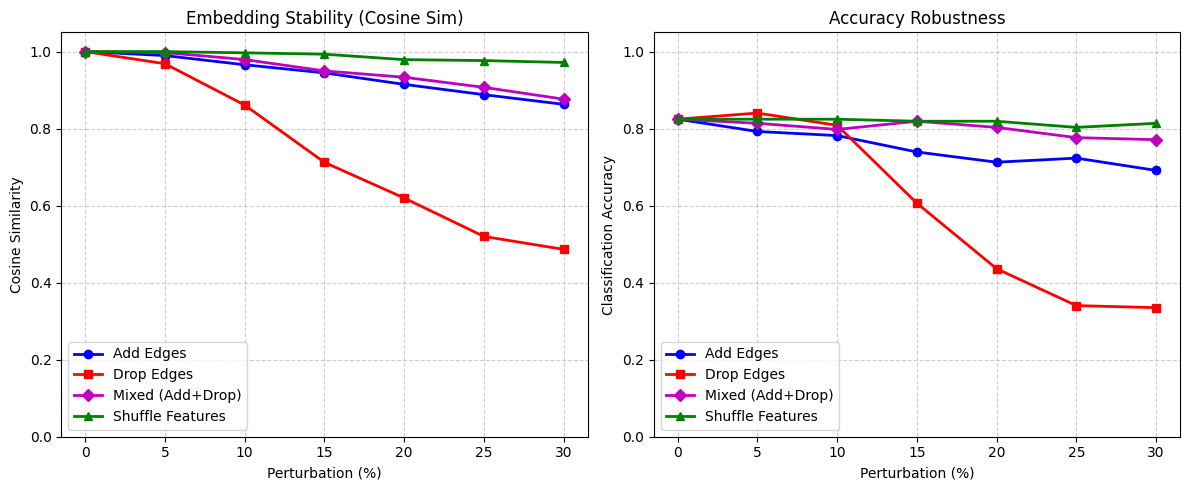


Saved full stability analysis to 'stability_analysis_MUTAG_128.png'



============================== CLASSIFICATION - 256 ==============================
[Fold 01] Acc: 0.9474 | F1: 0.9630 | AUC: 0.99 | Time: 4.88s
[Fold 02] Acc: 0.8947 | F1: 0.9286 | AUC: 0.97 | Time: 4.83s
[Fold 03] Acc: 0.9474 | F1: 0.9600 | AUC: 0.96 | Time: 4.77s
[Fold 04] Acc: 1.0000 | F1: 1.0000 | AUC: 1.00 | Time: 4.83s
[Fold 05] Acc: 0.9474 | F1: 0.9600 | AUC: 1.00 | Time: 4.78s
[Fold 06] Acc: 0.8947 | F1: 0.9231 | AUC: 0.92 | Time: 4.81s
[Fold 07] Acc: 0.8947 | F1: 0.9167 | AUC: 0.90 | Time: 4.75s
[Fold 08] Acc: 0.8947 | F1: 0.9091 | AUC: 0.88 | Time: 4.72s
[Fold 09] Acc: 0.8889 | F1: 0.9091 | AUC: 0.96 | Time: 4.79s
[Fold 10] Acc: 0.8889 | F1: 0.9167 | AUC: 0.89 | Time: 4.81s
------------------------------------------------------------
Final 10-Fold Results (MUTAG - EMB 256 - 150 EPOCHS):
Accuracy:        91.99% ± 3.62
F1-Score:        0.9386 ± 0.0289
AUC:             0.9473 ± 0.0433
Total Train Time:4.80s 

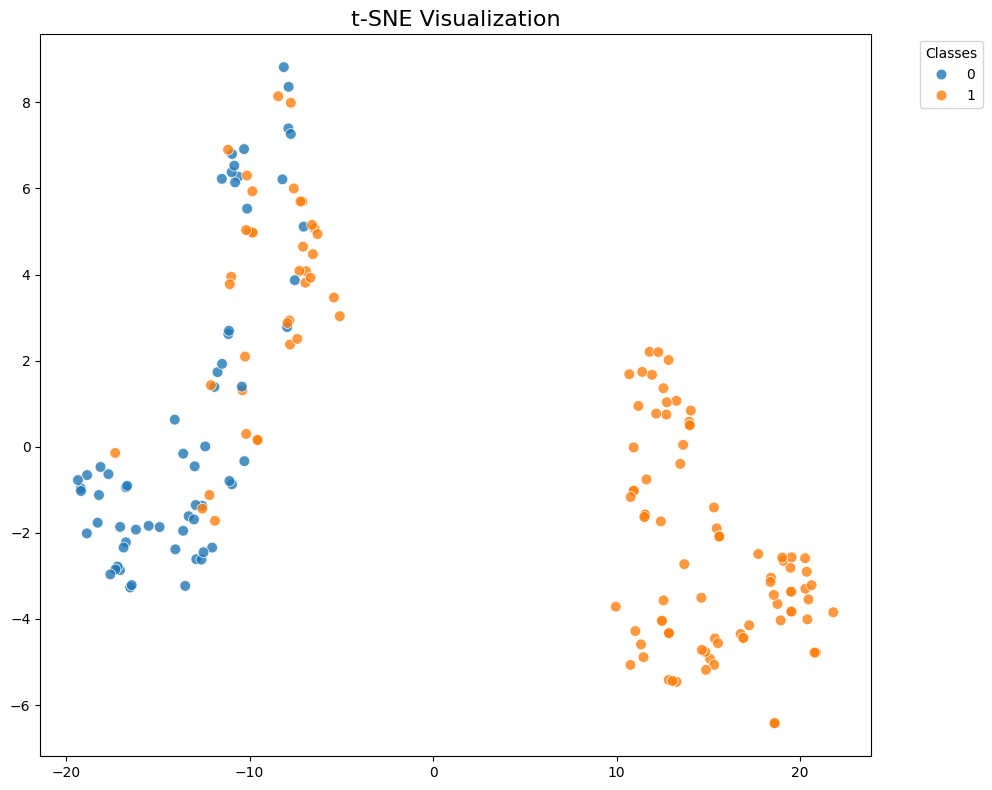

Saved: tSNE_MUTAG_256


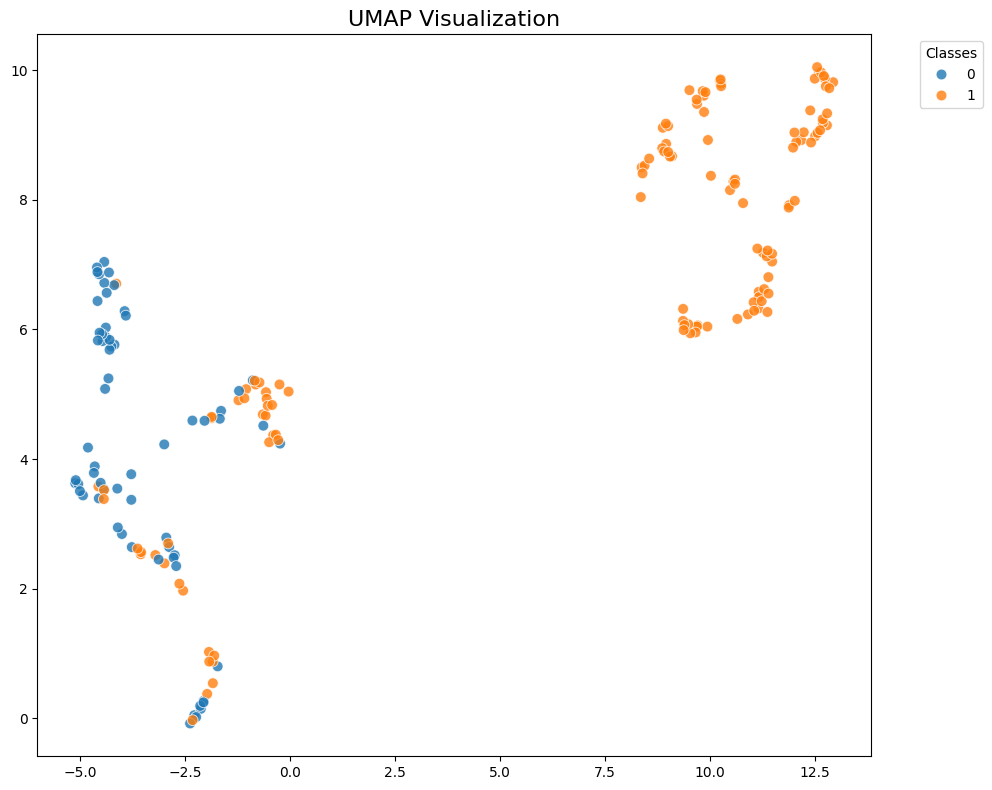

Saved: UMAP_MUTAG_256
-----------------------------------------
QUALITATIVE ASSESSMENT: Medium Separation
-----------------------------------------

============================== STABILITY ANALYSIS - 256 ==============================

[STABILITY] Computing baseline embeddings...
Baseline Accuracy: 0.8989

--- Running: Add Edges ---
Noise 5% | Stability: 0.9865 | Acc: 0.8670
Noise 10% | Stability: 0.9515 | Acc: 0.8564
Noise 15% | Stability: 0.9179 | Acc: 0.8085
Noise 20% | Stability: 0.8787 | Acc: 0.7766
Noise 25% | Stability: 0.8517 | Acc: 0.7766
Noise 30% | Stability: 0.8014 | Acc: 0.7394

--- Running: Drop Edges ---
Noise 5% | Stability: 0.9265 | Acc: 0.7553
Noise 10% | Stability: 0.7814 | Acc: 0.4255
Noise 15% | Stability: 0.6602 | Acc: 0.3404
Noise 20% | Stability: 0.5990 | Acc: 0.3351
Noise 25% | Stability: 0.5572 | Acc: 0.3351
Noise 30% | Stability: 0.5396 | Acc: 0.3351

--- Running: Mixed (Add+Drop) ---
Noise 5% | Stability: 0.9894 | Acc: 0.8670
Noise 10% | Stability: 0.9598 |

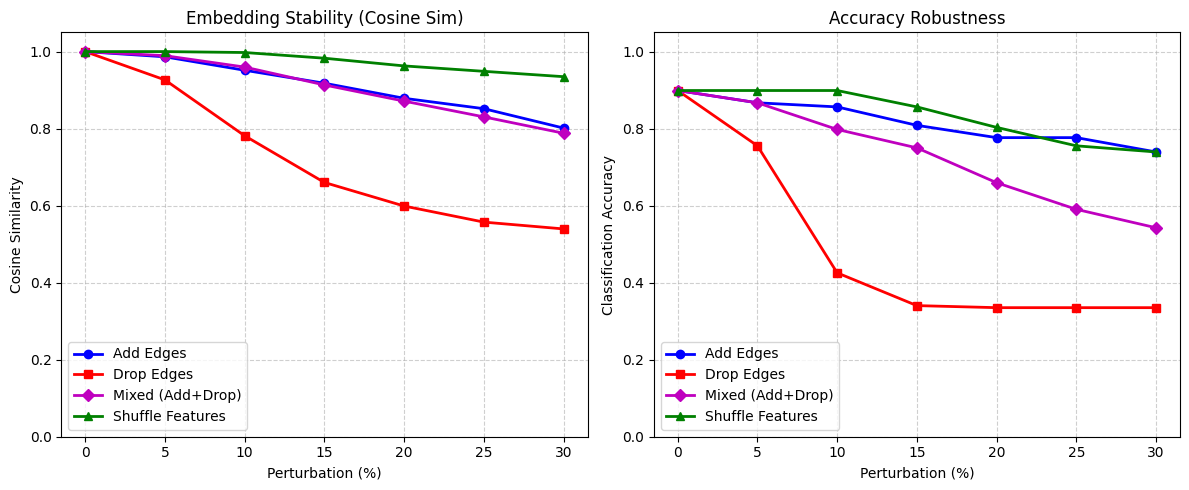


Saved full stability analysis to 'stability_analysis_MUTAG_256.png'



============================== CLASSIFICATION - 512 ==============================
[Fold 01] Acc: 0.9474 | F1: 0.9600 | AUC: 1.00 | Time: 4.96s
[Fold 02] Acc: 0.8421 | F1: 0.8889 | AUC: 0.94 | Time: 4.83s


In [ ]:
# CONFIGURATION
DATASET_NAME = 'MUTAG'  # Options: 'MUTAG', 'ENZYMES', 'IMDB-MULTI'
BATCH_SIZE = 64
EMBEDDING_SIZES = [16, 32, 64, 128, 256, 512, 1024]
# Our GIN implementation has 4 components (Layer0 + 3 GIN Layers) and the final embedding
# is the concatenation of each component's embedding, so the final embedding size is hidden_dim * 4
# HIDDEN_CHANNELS = int(EMBEDDING_SIZE/4) 
DROPOUT = 0.5
EPOCHS = 150
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# MAIN EMBEDDING TRIALS LOOP
for EMBEDDING_SIZE in EMBEDDING_SIZES:
    HIDDEN_CHANNELS = int(EMBEDDING_SIZE/4) 
        
    print(f"\n\n\n============================== CLASSIFICATION - {EMBEDDING_SIZE} ==============================")
    with open(f"./results/GIN_{DATASET_NAME}_results.txt", "a", encoding="utf-8") as f:
        f.write(f"\n\n==================== {DATASET_NAME} - {EMBEDDING_SIZE} ====================\n")
            
    # LOAD DATA
    dataset = get_dataset(DATASET_NAME)
    X = np.zeros(len(dataset)) # Dummy features for splitter
    y = np.array([data.y.item() for data in dataset]) # Labels for stratification
    # print(f"Dataset: {DATASET_NAME}")
    # print(f"Number of graphs: {len(dataset)}")
    # print(f"Number of classes: {dataset.num_classes}")
    # print(f"Number of node features: {dataset.num_features}")
    # print(f"Device: {device}")
    # print("-" * 60)
    
    # SETUP 10-FOLD SPLITTER
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    # Lists to store results across 10 folds
    results = {
        'acc': [], 'f1': [], 'auc': [], 
        'train_time': [], 'infer_time': [], 'memory': []
    }
    top_acc_so_far = 0
    
    # CROSS VALIDATION LOOP
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        # SPLIT DATA
        train_dataset = dataset[torch.tensor(train_idx)]
        test_dataset = dataset[torch.tensor(test_idx)]
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
        # SETUP MODEL
        model = GIN(
            in_channels=dataset.num_features, 
            hidden_channels=HIDDEN_CHANNELS, 
            out_channels=dataset.num_classes, 
            dropout=DROPOUT,
            num_layers=3,
        ).to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=0.00001)
    
        # TRAINING LOOP
        best_fold_metrics = {'acc': 0.0, 'f1': 0.0, 'auc': 0.0, 'infer_time': 0.0}
        total_train_time = 0.0
        
        # Reset GPU memory tracking for this fold
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
    
        for epoch in range(EPOCHS): 
            # Measure Training Time
            start_train = time.time()
            train_loss = train(model, train_loader, optimizer)
            total_train_time += (time.time() - start_train)
            
            # Measure Generation (Inference) Time
            start_infer = time.time()
            y_true, y_pred, y_probs, _ = test(model, test_loader)
            infer_time = time.time() - start_infer
            
            test_acc = (y_pred == y_true).sum() / len(y_true)
            scheduler.step(train_loss)     
    
            # If this is the best model so far (in this fold), calculate and store all detailed metrics
            if test_acc > best_fold_metrics['acc']:
                best_fold_metrics['acc'] = test_acc
                best_fold_metrics['infer_time'] = infer_time
                
                # Calculate F1 and AUC
                try:
                    if dataset.num_classes == 2:
                        # For binary, pass only the positive class probability
                        best_fold_metrics['auc'] = roc_auc_score(y_true, y_probs[:, 1])
                        best_fold_metrics['f1'] = f1_score(y_true, y_pred, average='binary')
                    else:
                        best_fold_metrics['auc'] = roc_auc_score(y_true, y_probs, multi_class='ovr', average='weighted')
                        best_fold_metrics['f1'] = f1_score(y_true, y_pred, average='weighted')
                except ValueError:
                    best_fold_metrics['auc'] = 0.5
    
                # Save the best model across folds
                if test_acc > top_acc_so_far:
                    top_acc_so_far = test_acc
                    torch.save(model.state_dict(), './best_models/best_model.pth')
                    
        # Record Memory (Peak VRAM used during this fold in MB)
        max_memory = torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0
    
        # Append Fold Results
        results['acc'].append(best_fold_metrics['acc'])
        results['f1'].append(best_fold_metrics['f1'])
        results['auc'].append(best_fold_metrics['auc'])
        results['train_time'].append(total_train_time)
        results['infer_time'].append(best_fold_metrics['infer_time'])
        results['memory'].append(max_memory)
        
        print(f"[Fold {fold+1:02d}] Acc: {best_fold_metrics['acc']:.4f} | F1: {best_fold_metrics['f1']:.4f} | AUC: {best_fold_metrics['auc']:.2f} | Time: {total_train_time:.2f}s")
    
    # PRINT FINAL RESULTS
    report = (
    "------------------------------------------------------------" + "\n"
    f"Final 10-Fold Results ({DATASET_NAME} - EMB {EMBEDDING_SIZE} - {EPOCHS} EPOCHS):\n"
    f"Accuracy:        {np.mean(results['acc'])*100:.2f}% ± {np.std(results['acc'])*100:.2f}\n"
    f"F1-Score:        {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}\n"
    f"AUC:             {np.mean(results['auc']):.4f} ± {np.std(results['auc']):.4f}\n"
    f"Total Train Time:{np.mean(results['train_time']):.2f}s ± {np.std(results['train_time']):.2f}\n"
    f"Avg Inference:   {np.mean(results['infer_time']):.4f}s ± {np.std(results['infer_time']):.4f}\n"
    f"Peak Memory Use: {np.mean(results['memory']):.2f} MB\n"
    "------------------------------------------------------------" + "\n"
    )
    
    # Append to the output file
    with open(f"./results/GIN_{DATASET_NAME}_results.txt", "a", encoding="utf-8") as f:
        f.write(report)
        print(report)

    # Save the average baseline accuracy for comparison in the stability analysis
    avg_baseline_acc = np.mean(results['acc'])


    print(f"\n============================== CLUSTERING - {EMBEDDING_SIZE} ==============================")

    # EXTRACT GRAPH EMBEDDINGS FROM THE ENTIRE DATASETS
    full_loader = DataLoader(dataset, batch_size=64, shuffle=False) # no shuffle for consistent plotting
    
    # Get Embeddings using the best model from training
    model.load_state_dict(torch.load('./best_models/best_model.pth'))
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for data in full_loader:
            data = data.to(device)
            _, _, embeddings = model(data.x, data.edge_index, data.batch)
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.append(data.y.cpu().numpy())
    
    X_emb = np.concatenate(all_embeddings, axis=0)
    y_true = np.concatenate(all_labels, axis=0)
    
    print(f"Graph Embeddings Shape: {X_emb.shape}")
    
    # CLUSTERING & METRICS (ARI)
    num_classes = dataset.num_classes
    
    # K-Means
    kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
    y_kmeans = kmeans.fit_predict(X_emb)
    ari_kmeans = adjusted_rand_score(y_true, y_kmeans)
    
    # Spectral Clustering
    spectral = SpectralClustering(n_clusters=num_classes, assign_labels='cluster_qr', random_state=42)
    y_spectral = spectral.fit_predict(X_emb)
    ari_spectral = adjusted_rand_score(y_true, y_spectral)
    
    print("-" * 29)
    print(f"Clustering Performance (ARI):")
    print(f"K-Means ARI:              {ari_kmeans:.4f}")
    print(f"Spectral Clustering ARI:  {ari_spectral:.4f}")
    print("-" * 29)
    
    # VISUALIZATION (t-SNE & UMAP)
    tsne = TSNE(n_components=2, random_state=42)
    z_tsne = tsne.fit_transform(X_emb)
    
    umap_model = umap.UMAP(n_components=2, random_state=42)
    z_umap = umap_model.fit_transform(X_emb)
    
    def plot_embedding(z, labels, title, filename):
        plt.figure(figsize=(10, 8))
        sns.scatterplot(x=z[:,0], y=z[:,1], hue=labels, palette='tab10', s=60, alpha=0.8)
        plt.title(title, fontsize=16)
        plt.legend(title='Classes', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(f"./plots/{filename}")
        plt.show()
        print(f"Saved: {filename}")
    
    warnings.filterwarnings('ignore', message='.*n_jobs value 1 overridden.*')
    plot_embedding(z_tsne, y_true, "t-SNE Visualization", f"tSNE_{DATASET_NAME}_{EMBEDDING_SIZE}")
    plot_embedding(z_umap, y_true, "UMAP Visualization", f"UMAP_{DATASET_NAME}_{EMBEDDING_SIZE}")
    
    # QUALITATIVE ASSESSMENT
    def assess_separation(ari_score):
        if ari_score > 0.5:
            return "Clear Separation"
        elif ari_score > 0.2:
            return "Medium Separation"
        else:
            return "No/Poor Separation"
    
    quality = assess_separation(max(ari_kmeans, ari_spectral))
    print("-" * 41)
    print(f"QUALITATIVE ASSESSMENT: {quality}")
    print("-" * 41)

    # PRINT FINAL RESULTS
    report = (
        f"K-Means ARI:              {ari_kmeans:.4f}" + "\n"
        f"Spectral Clustering ARI:  {ari_spectral:.4f}" + "\n"
        f"QUALITATIVE ASSESSMENT: {quality}" + "\n"
        "------------------------------------------------------------" + "\n"
    )
    
    # Append to the output file
    with open(f"./results/GIN_{DATASET_NAME}_results.txt", "a", encoding="utf-8") as f:
        f.write(report)



    print(f"\n============================== STABILITY ANALYSIS - {EMBEDDING_SIZE} ==============================")
    
    # PERTURBATION FUNCTIONS
    def perturb_add_edges(data, noise_level):
        """Adds noise_level * num_edges random edges."""
        if noise_level == 0: return data
        data = data.clone()
        num_nodes = data.num_nodes
        num_existing = data.edge_index.size(1)
        num_to_add = int(num_existing * noise_level)
        
        if num_to_add > 0:
            row = torch.randint(0, num_nodes, (num_to_add,), dtype=torch.long)
            col = torch.randint(0, num_nodes, (num_to_add,), dtype=torch.long)
            mask = row != col # Avoid self-loops
            new_edges = torch.stack([row[mask], col[mask]], dim=0)
            data.edge_index = torch.cat([data.edge_index, new_edges], dim=1)
        return data
    
    def perturb_drop_edges(data, noise_level):
        """Removes noise_level * num_edges existing edges."""
        if noise_level == 0: return data
        data = data.clone()
        num_edges = data.edge_index.size(1)
        num_to_drop = int(num_edges * noise_level)
        
        if num_to_drop > 0:
            # We prefer to keep edges, so we calculate how many to keep
            num_keep = num_edges - num_to_drop
            # Random permutation of indices
            perm = torch.randperm(num_edges)
            keep_indices = perm[:num_keep]
            data.edge_index = data.edge_index[:, keep_indices]
        return data
    
    def perturb_add_drop_edges(data, noise_level):
        """
        Simultaneously adds (noise/2) edges and drops (noise/2) edges.
        Example: noise_level 0.05 adds 2.5% edges and drops 2.5% edges.
        """
        if noise_level == 0: return data
        
        # Split the budget
        half_noise = noise_level / 2.0
        
        # 1. Add Edges first
        data = perturb_add_edges(data, half_noise)
        
        # 2. Drop Edges (from the new graph)
        data = perturb_drop_edges(data, half_noise)
        
        return data
    
    def perturb_shuffle_features(data, noise_level):
        """Shuffles the feature vectors of noise_level * num_nodes nodes."""
        if noise_level == 0: return data
        # If dataset has no features (like IMDB-MULTI raw), skip or handle
        if data.x is None: return data
        
        data = data.clone()
        num_nodes = data.num_nodes
        num_to_shuffle = int(num_nodes * noise_level)
        
        if num_to_shuffle > 1:
            # Select random nodes to shuffle
            perm = torch.randperm(num_nodes)
            nodes_to_shuffle = perm[:num_to_shuffle]
            
            # Get their features
            features = data.x[nodes_to_shuffle]
            
            # Shuffle these features among themselves
            shuffled_indices = torch.randperm(num_to_shuffle)
            data.x[nodes_to_shuffle] = features[shuffled_indices]
            
        return data
    
    # Dictionary mapping perturbation names to functions
    perturbation_types = {
        'Add Edges': perturb_add_edges,
        'Drop Edges': perturb_drop_edges,
        'Mixed (Add+Drop)': perturb_add_drop_edges,  
        'Shuffle Features': perturb_shuffle_features
    }
    
    
    # RUN EXPERIMENTS
    noise_levels = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
    results = {name: {'stability': [], 'accuracy': []} for name in perturbation_types}
    
    # Compute Baseline (Noise = 0)
    print("\n[STABILITY] Computing baseline embeddings...")
    # Get Embeddings using the best model from training
    model.load_state_dict(torch.load('./best_models/best_model.pth'))
    base_loader = DataLoader(dataset, batch_size=64, shuffle=False)

    base_embeddings = []
    base_labels = [] 

    with torch.no_grad():
        for data in base_loader:
            data = data.to(device)
            _, _, emb = model(data.x, data.edge_index, data.batch)
            base_embeddings.append(emb)
            base_labels.append(data.y)

    base_emb_tensor = torch.cat(base_embeddings, dim=0)
    base_labels_tensor = torch.cat(base_labels, dim=0)
    
    # Calculate Baseline Accuracy (using the classifier head)
    with torch.no_grad():
        # Re-run classifier part manually or just use predictions from loop if saved
        # Here we reconstruct predictions from embeddings for consistency
        h = model.lin1(base_emb_tensor)
        h = h.relu()
        # Note: Training=False for dropout
        out = model.lin2(h) 
        base_preds = out.argmax(dim=1)

    base_acc = accuracy_score(base_labels_tensor.cpu(), base_preds.cpu())
    print(f"Baseline Accuracy: {base_acc:.4f}")
    with open(f"./results/GIN_{DATASET_NAME}_{EMBEDDING_SIZE}_results.txt", "a", encoding="utf-8") as f:
        f.write(f"Baseline Accuracy: {base_acc:.4f}" + "\n")
    
    # Loop Over Perturbations
    for p_name, p_func in perturbation_types.items():
        print(f"\n--- Running: {p_name} ---")
        with open(f"./results/GIN_{DATASET_NAME}_results.txt", "a", encoding="utf-8") as f:
            f.write(f"\n--- Running: {p_name} ---" + "\n")
        
        for noise in noise_levels:
            if noise == 0.00:
                results[p_name]['stability'].append(1.0)
                results[p_name]['accuracy'].append(base_acc)
                continue
                
            # 1. Generate Perturbed Dataset
            # Note: For Shuffle Features on IMDB-MULTI (OneHotDegree), 
            # features are generated on fly by transform. 
            # We apply perturbation AFTER transform (on the data object).
            noisy_data_list = []
            for d in dataset:
                # We must ensure d has x if we rely on OneHotDegree transform
                # The dataset[i] access applies transforms.
                d_perturbed = p_func(d, noise)
                noisy_data_list.append(d_perturbed)
                
            noisy_loader = DataLoader(noisy_data_list, batch_size=64, shuffle=False)
            
            # 2. Get Embeddings & Preds
            curr_embeddings = []
            curr_preds = []
            with torch.no_grad():
                for data in noisy_loader:
                    data = data.to(device)
                    _, probs, emb = model(data.x, data.edge_index, data.batch)
                    curr_embeddings.append(emb)
                    curr_preds.append(probs.argmax(dim=1))
            
            noisy_emb_tensor = torch.cat(curr_embeddings, dim=0)
            noisy_pred_tensor = torch.cat(curr_preds, dim=0)
            
            # 3. Compute Metrics
            # Cosine Similarity (Embedding Stability)
            cos_sim = F.cosine_similarity(base_emb_tensor, noisy_emb_tensor, dim=1).mean().item()
            
            # Accuracy
            acc = accuracy_score(base_labels_tensor.cpu(), noisy_pred_tensor.cpu())
            
            results[p_name]['stability'].append(cos_sim)
            results[p_name]['accuracy'].append(acc)
            
            print(f"Noise {int(noise*100)}% | Stability: {cos_sim:.4f} | Acc: {acc:.4f}")
            with open(f"./results/GIN_{DATASET_NAME}_results.txt", "a", encoding="utf-8") as f:
                f.write(f"Noise {int(noise*100)}% | Stability: {cos_sim:.4f} | Acc: {acc:.4f}" + "\n")
    
    # VISUALIZATION
    plt.figure(figsize=(12, 5))
    markers = {'Add Edges': 'o', 'Drop Edges': 's', 'Shuffle Features': '^', 'Mixed (Add+Drop)': 'D'}
    colors  = {'Add Edges': 'b', 'Drop Edges': 'r', 'Shuffle Features': 'g', 'Mixed (Add+Drop)': 'm'}
    
    # Plot 1: Embedding Stability
    plt.subplot(1, 2, 1)
    for name, data in results.items():
        plt.plot([n*100 for n in noise_levels], data['stability'], 
                 marker=markers[name], color=colors[name], label=name, linewidth=2)
        
    plt.title('Embedding Stability (Cosine Sim)')
    plt.xlabel('Perturbation (%)')
    plt.ylabel('Cosine Similarity')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.ylim(0, 1.05)
    
    # Plot 2: Accuracy Degradation
    plt.subplot(1, 2, 2)
    for name, data in results.items():
        plt.plot([n*100 for n in noise_levels], data['accuracy'], 
                 marker=markers[name], color=colors[name], label=name, linewidth=2)
    
    plt.title('Accuracy Robustness')
    plt.xlabel('Perturbation (%)')
    plt.ylabel('Classification Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.ylim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig(f'./plots/stability_analysis_{DATASET_NAME}_{EMBEDDING_SIZE}.png')
    plt.show()
    
    print(f"\nSaved full stability analysis to 'stability_analysis_{DATASET_NAME}_{EMBEDDING_SIZE}.png'")